In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    "../data/processed/aufschreibung_mta_clean.csv",
    sep=","
)

print("Data loaded successfully")


Data loaded successfully


Generiere Diagramme für 33 Maschinen...


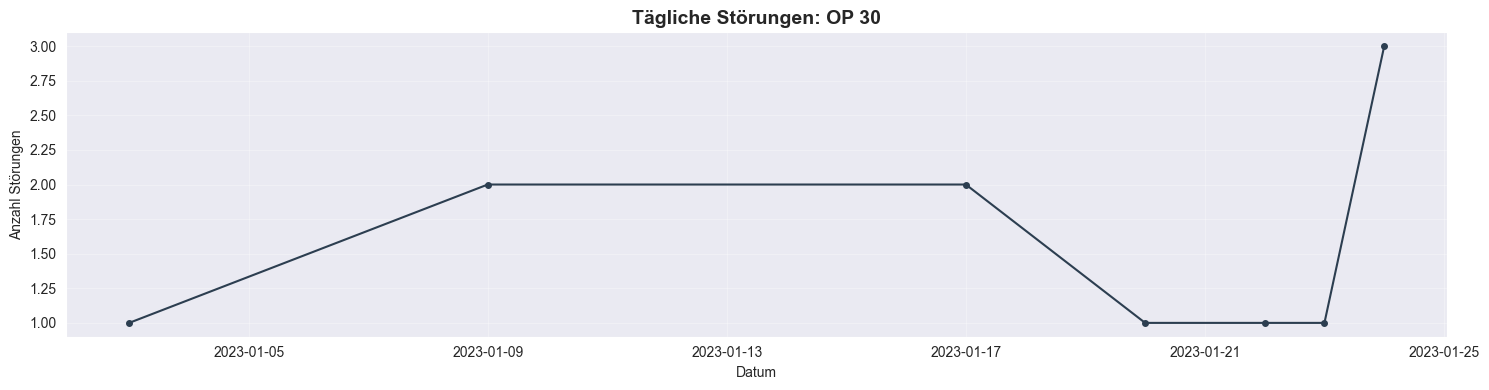

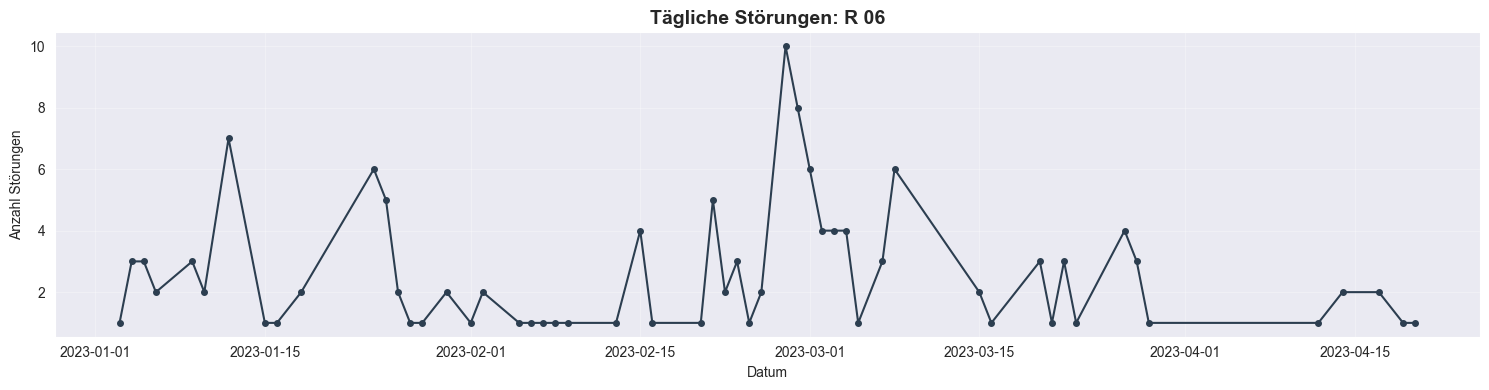

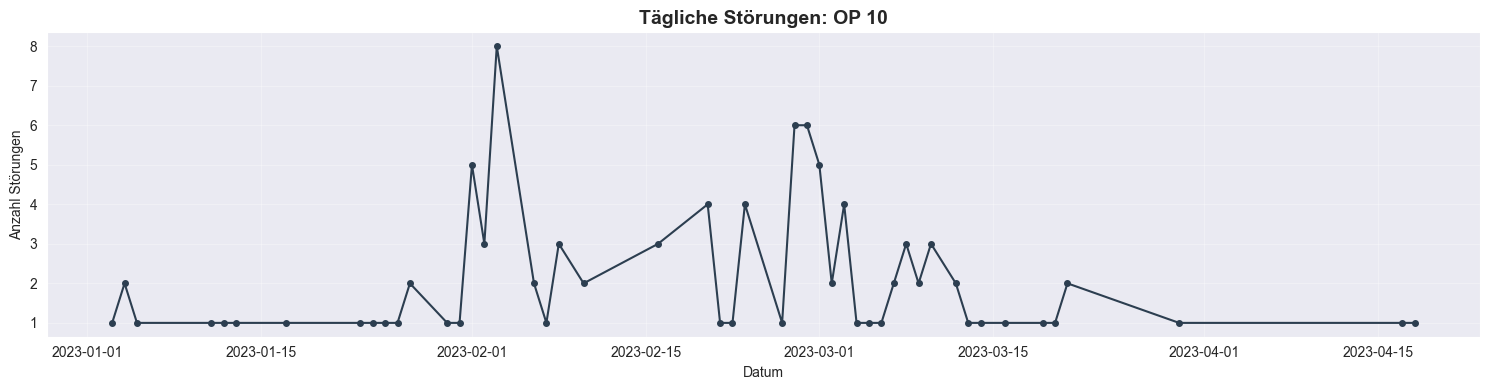

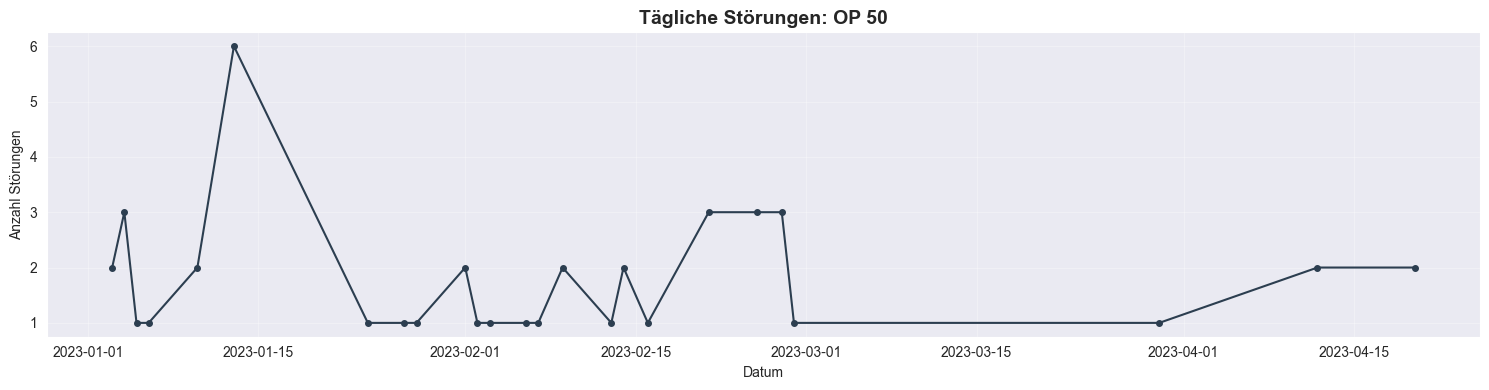

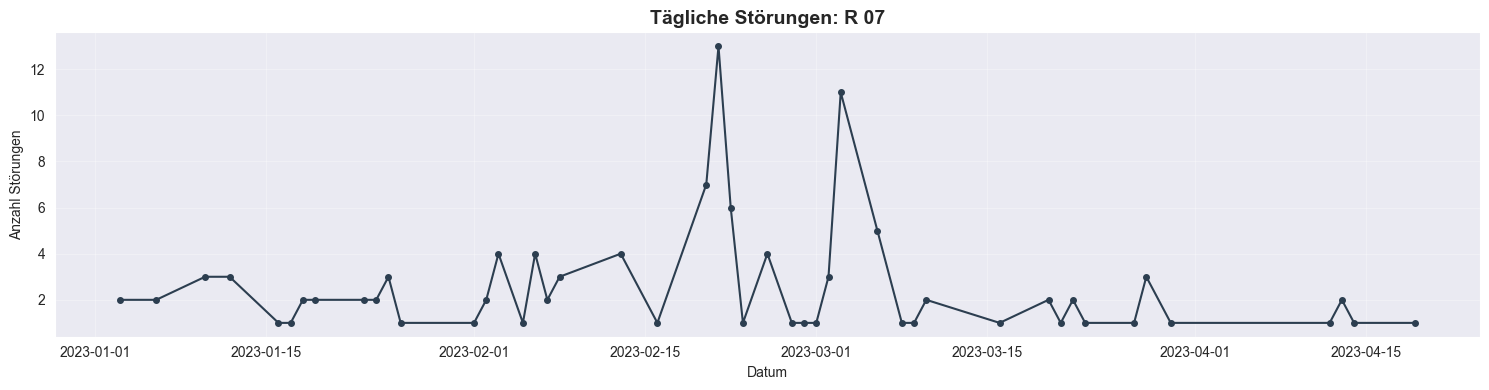

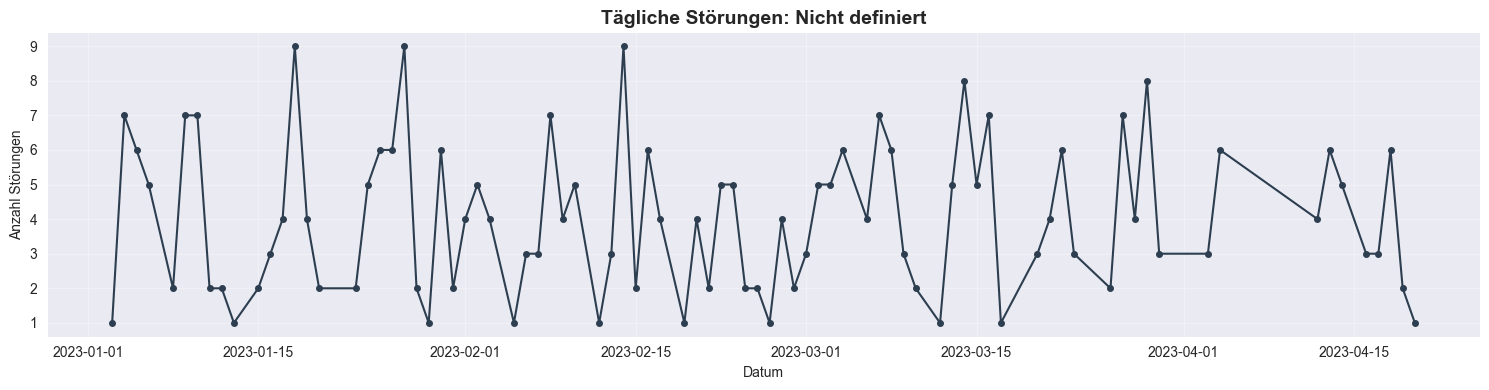

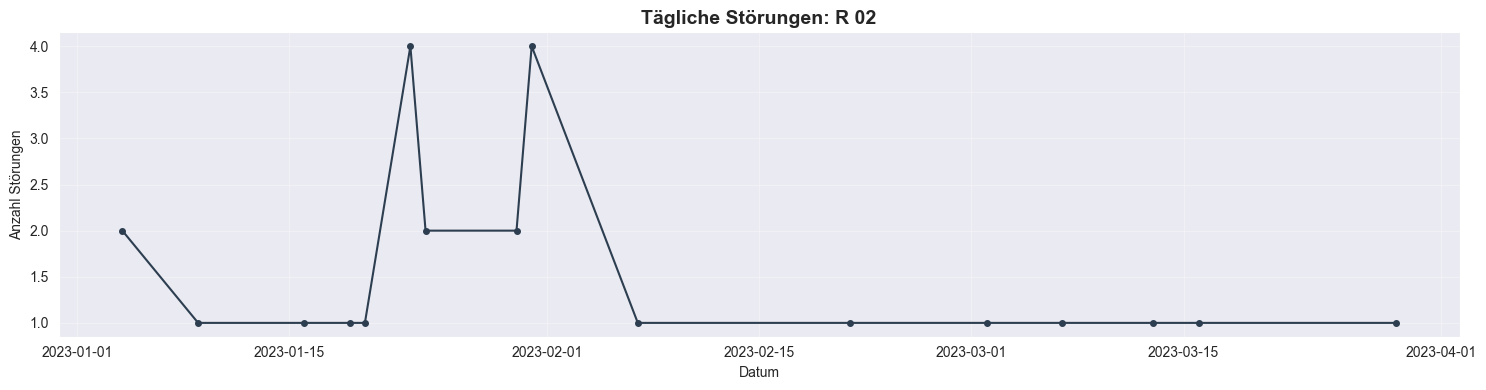

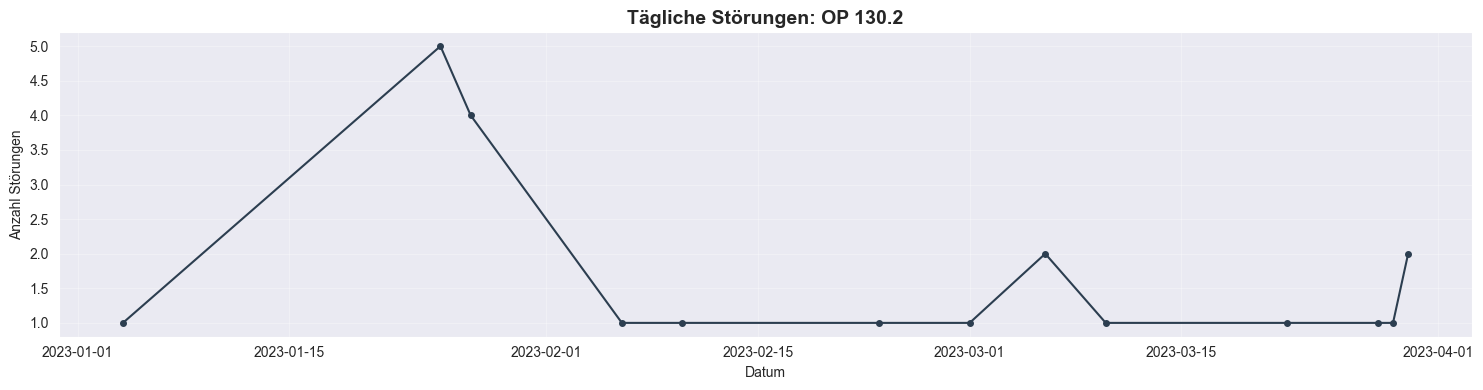

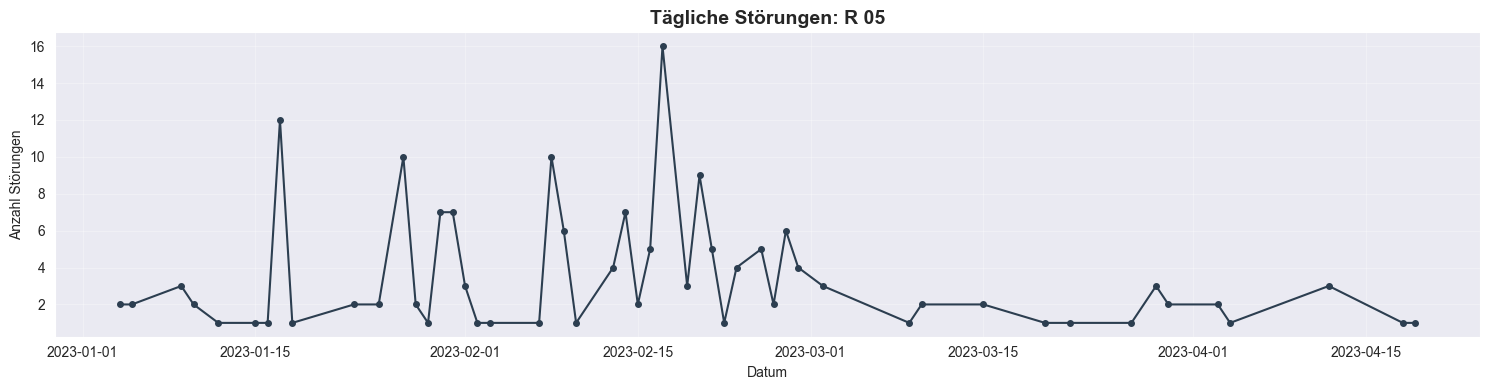

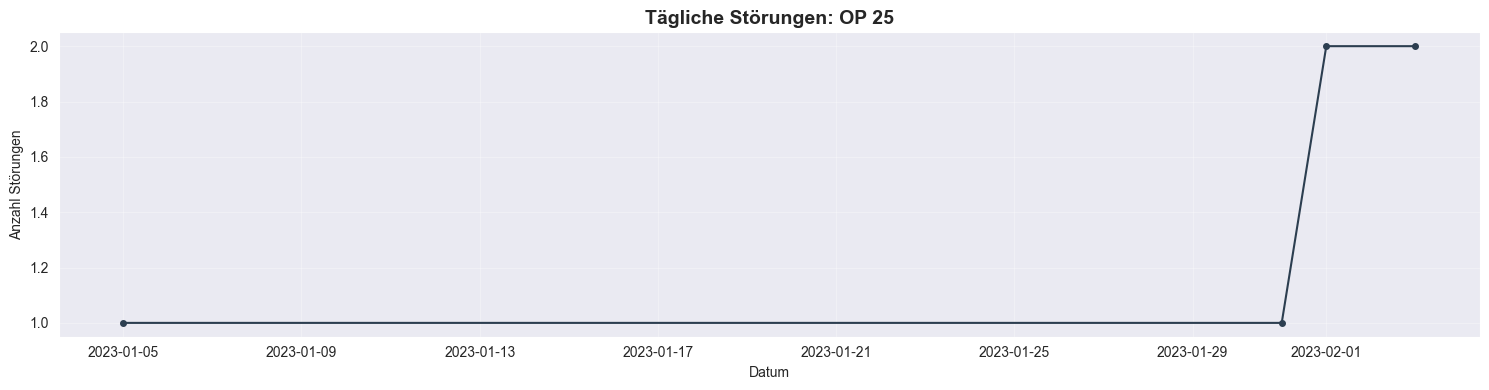

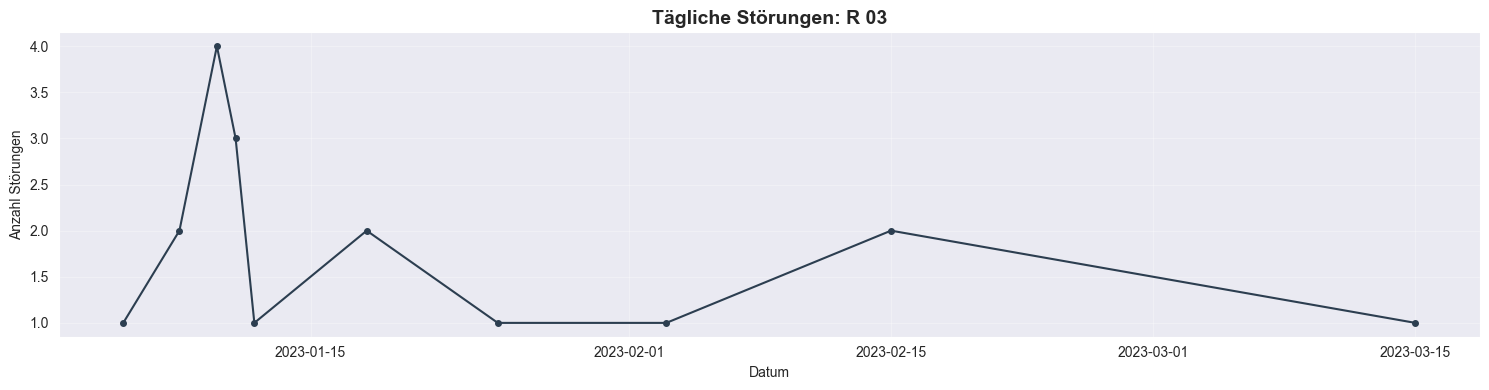

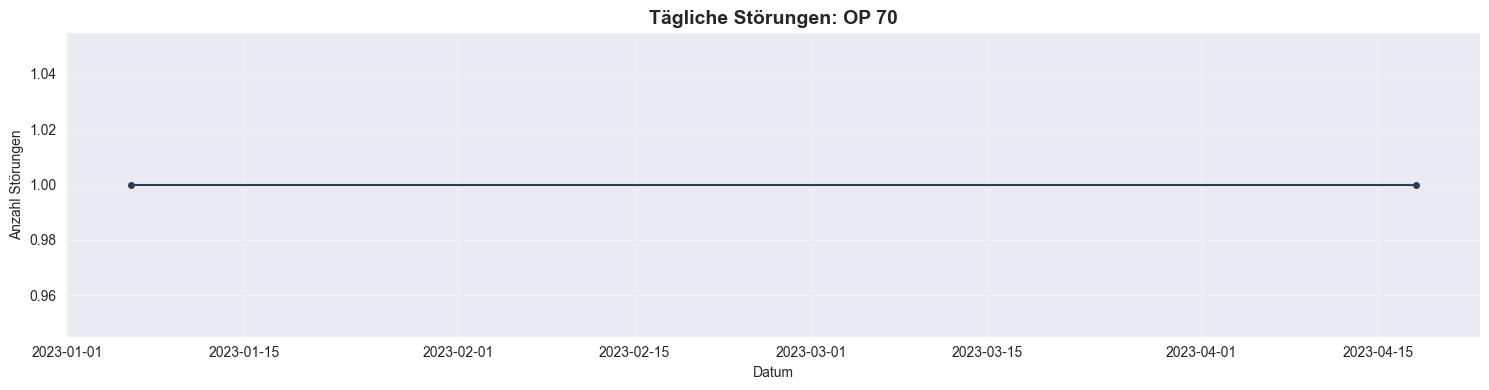

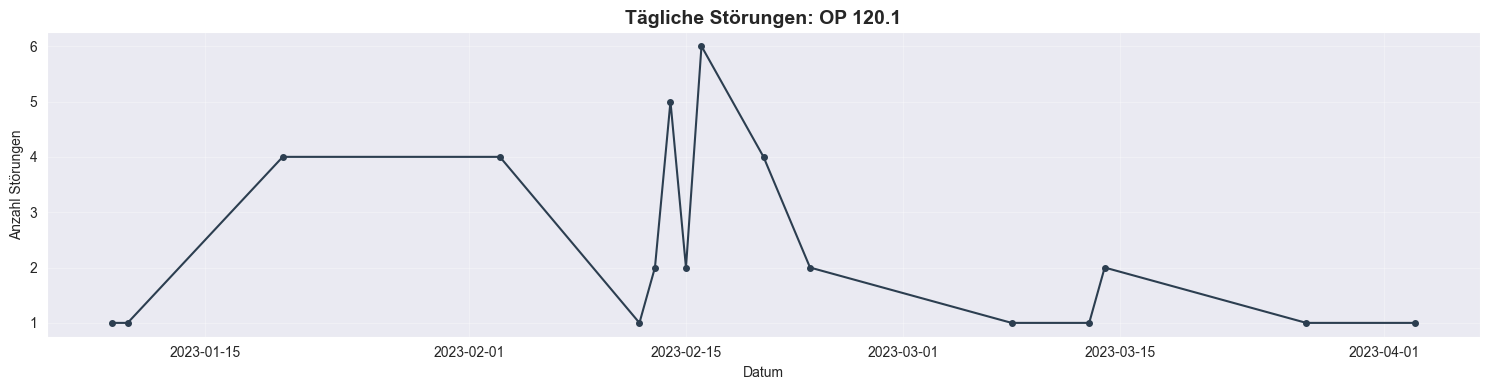

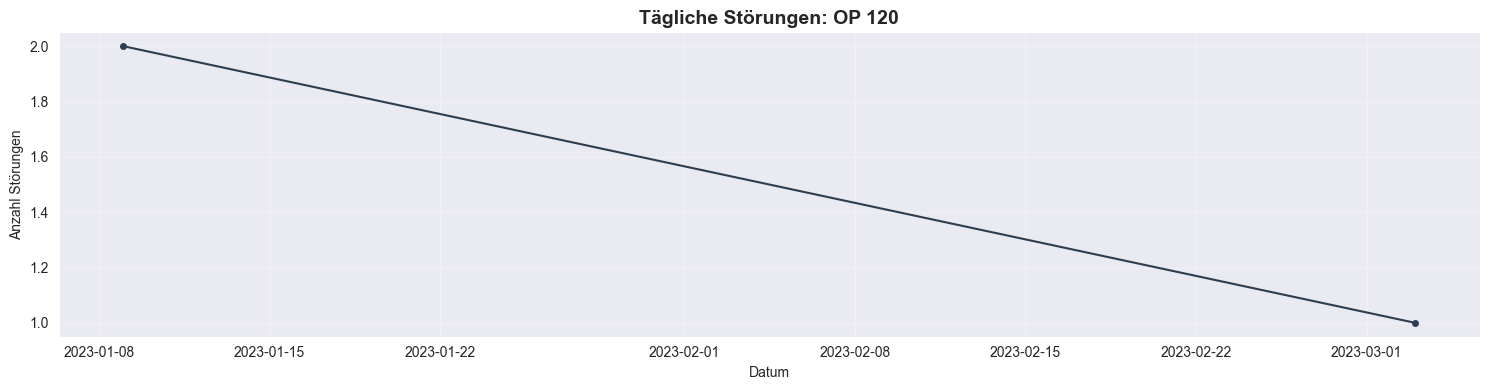

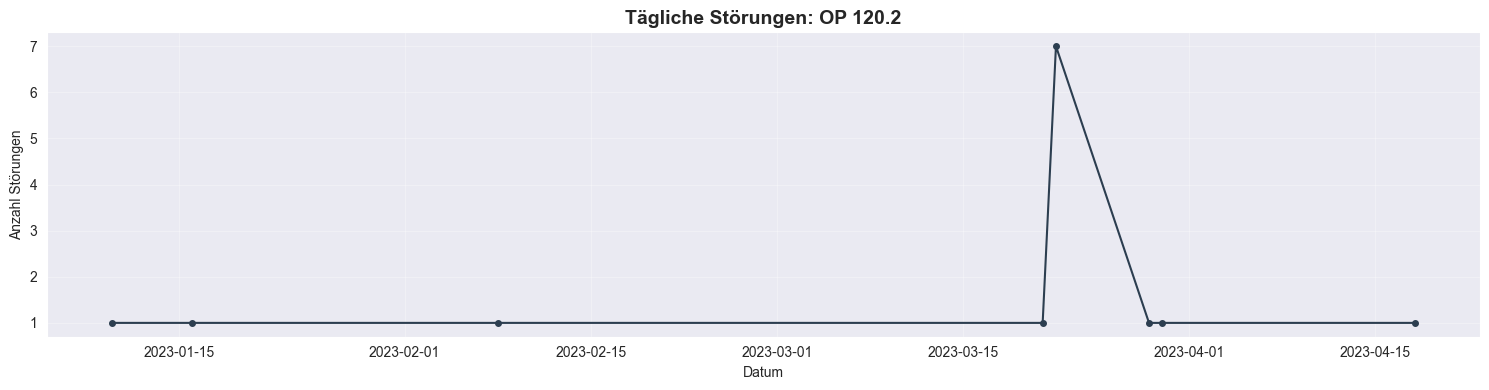

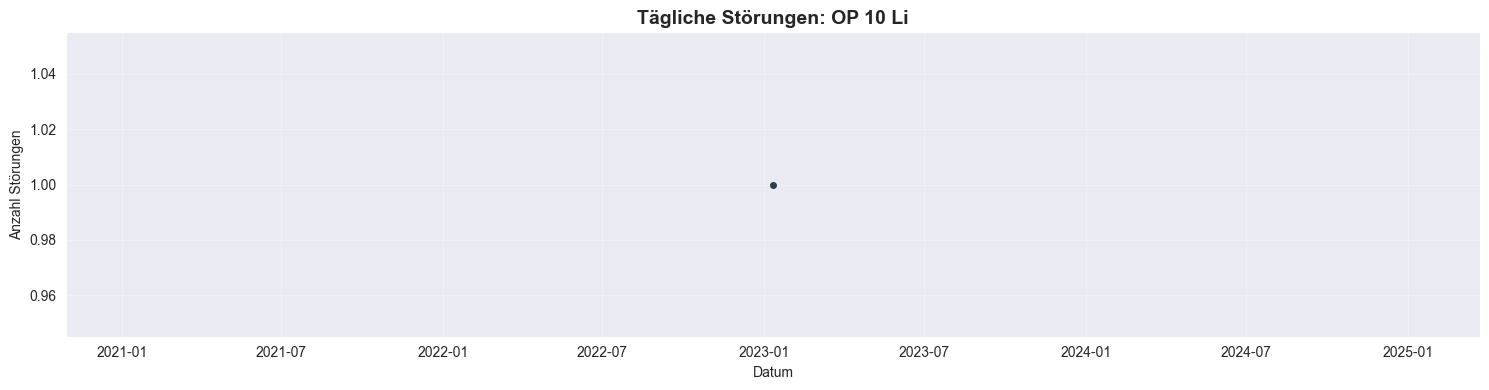

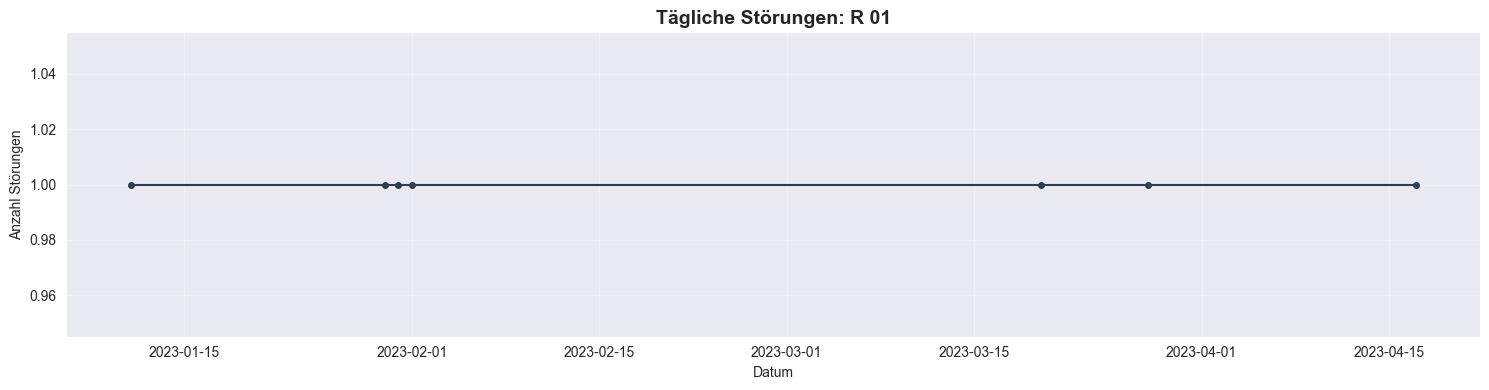

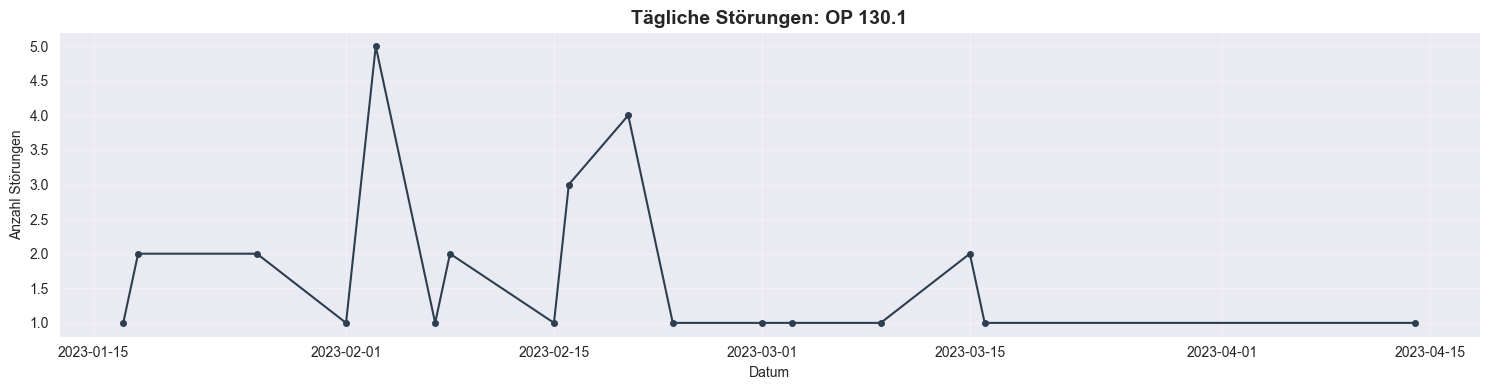

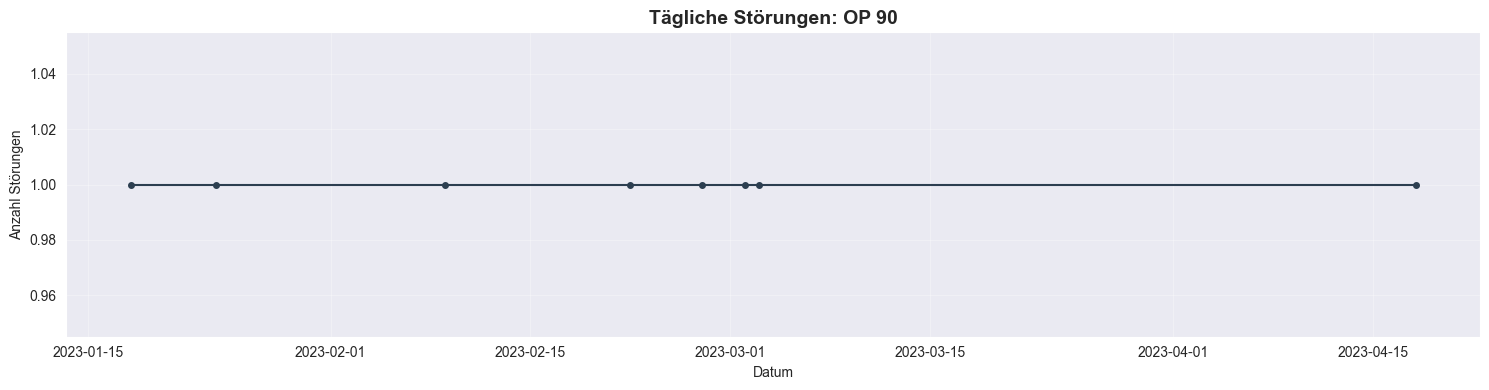

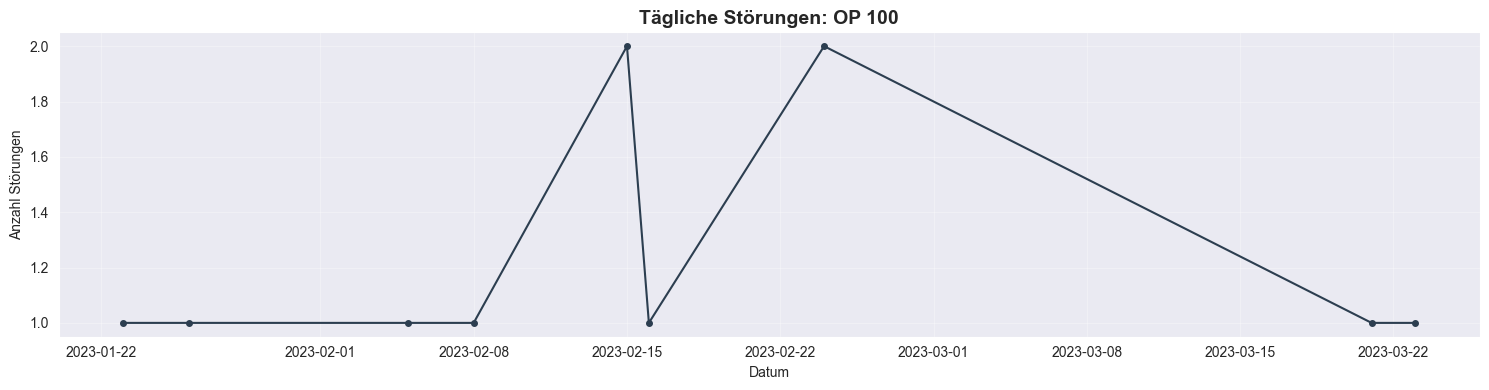

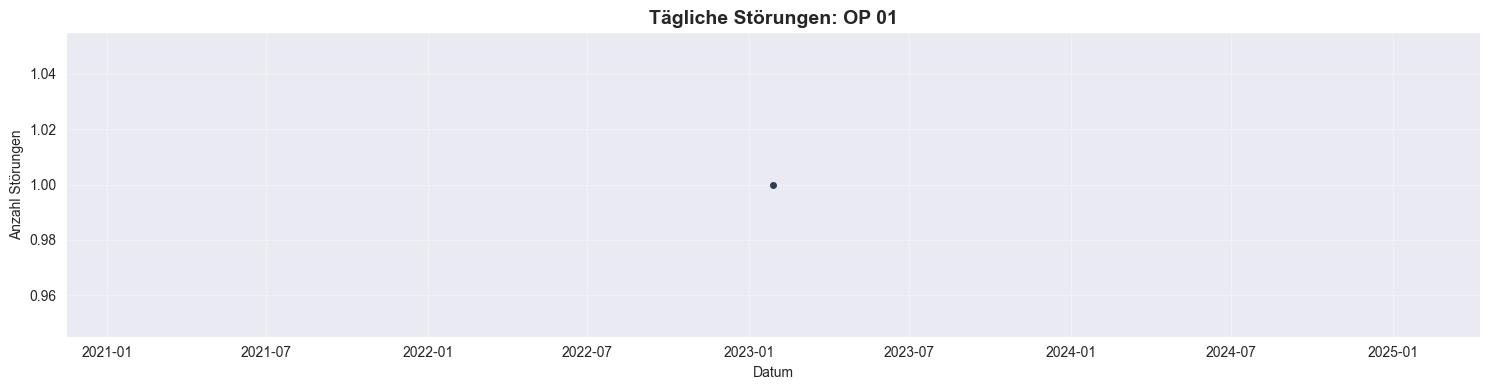

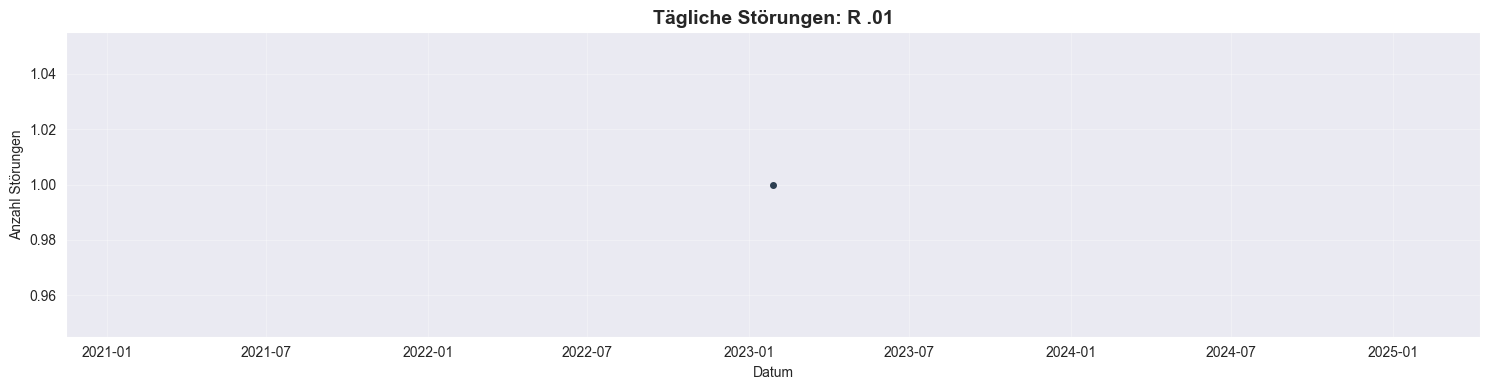

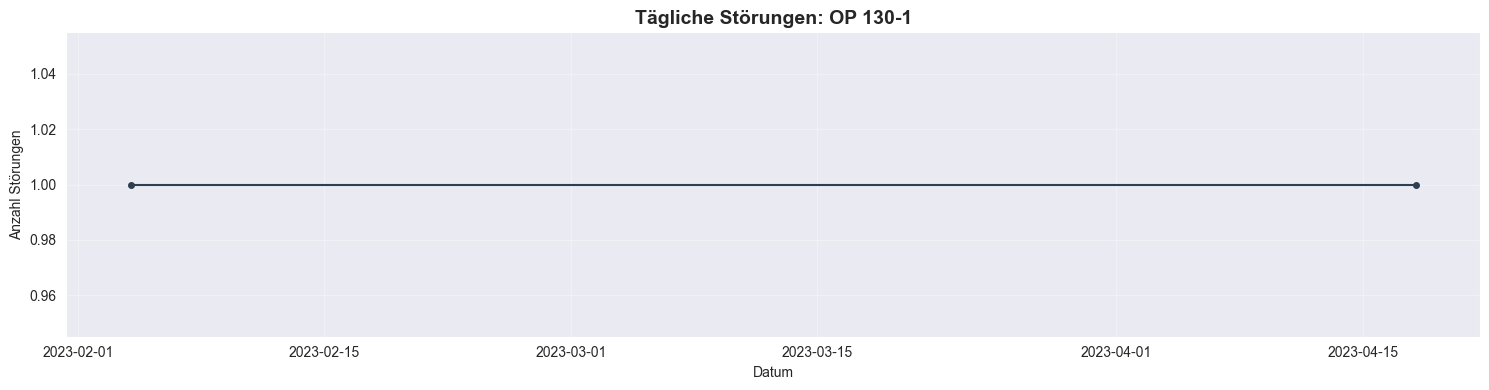

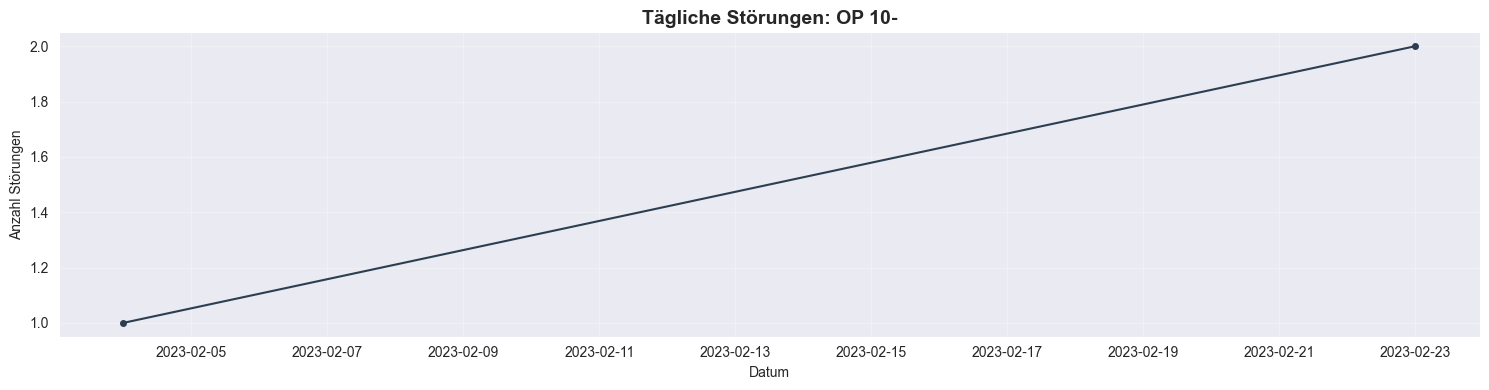

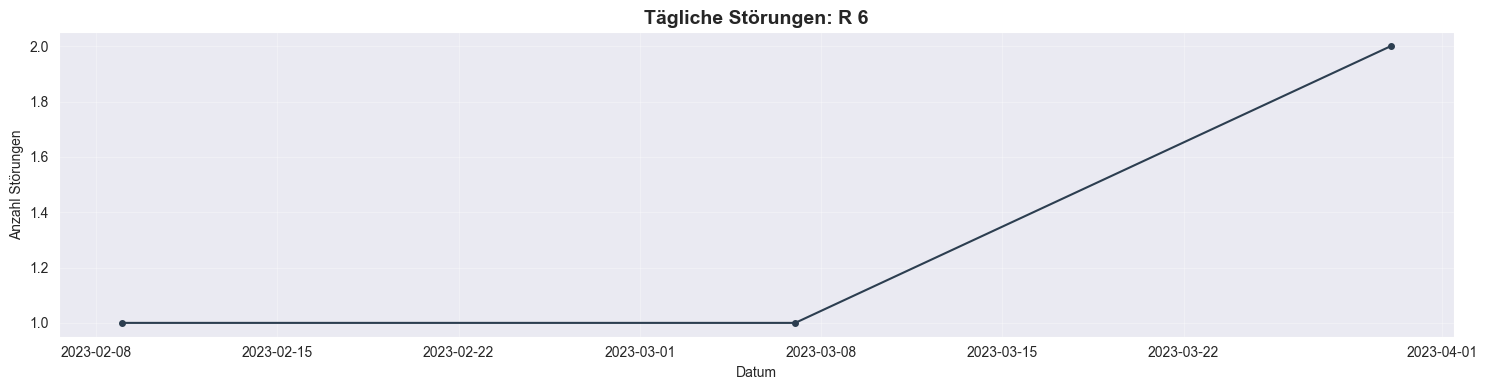

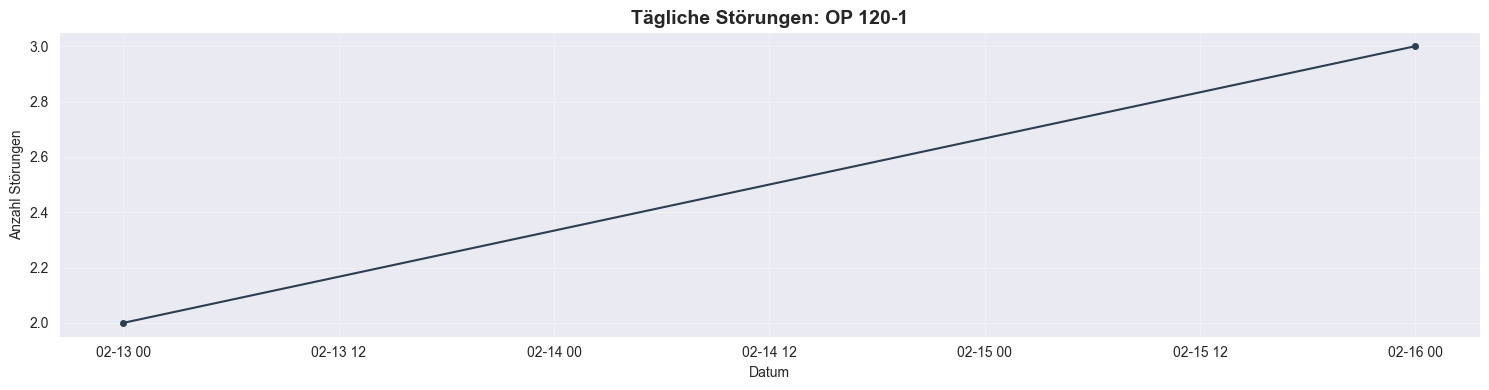

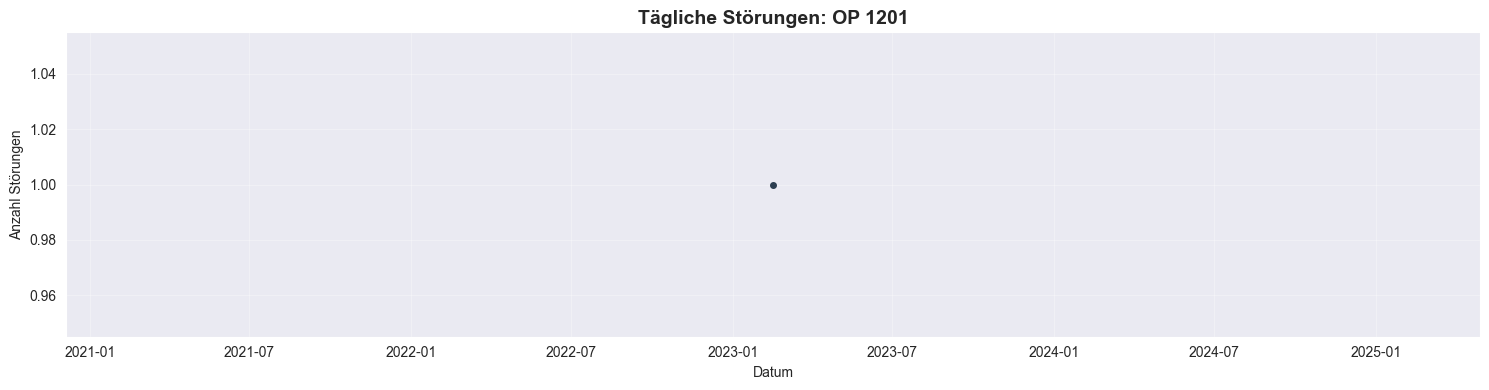

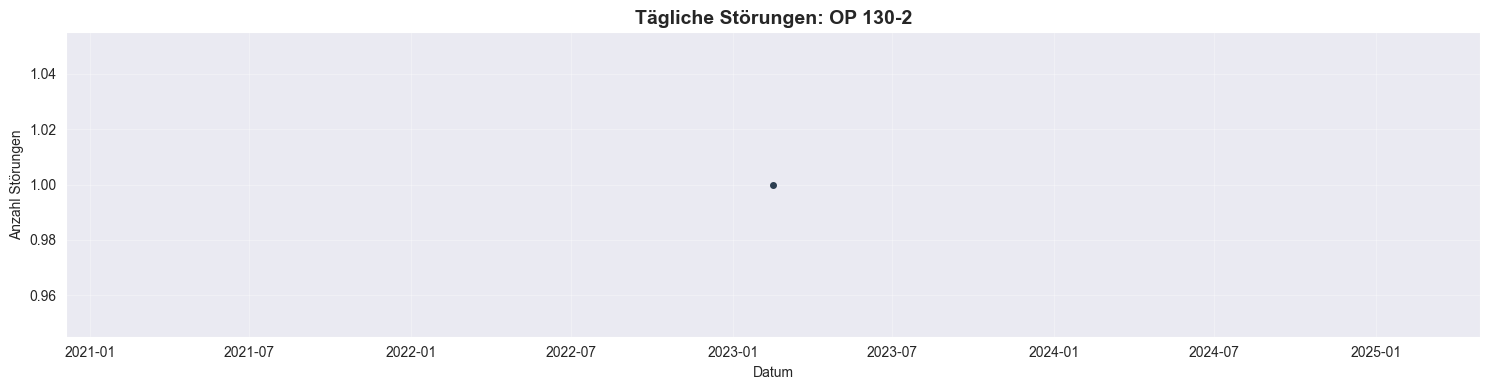

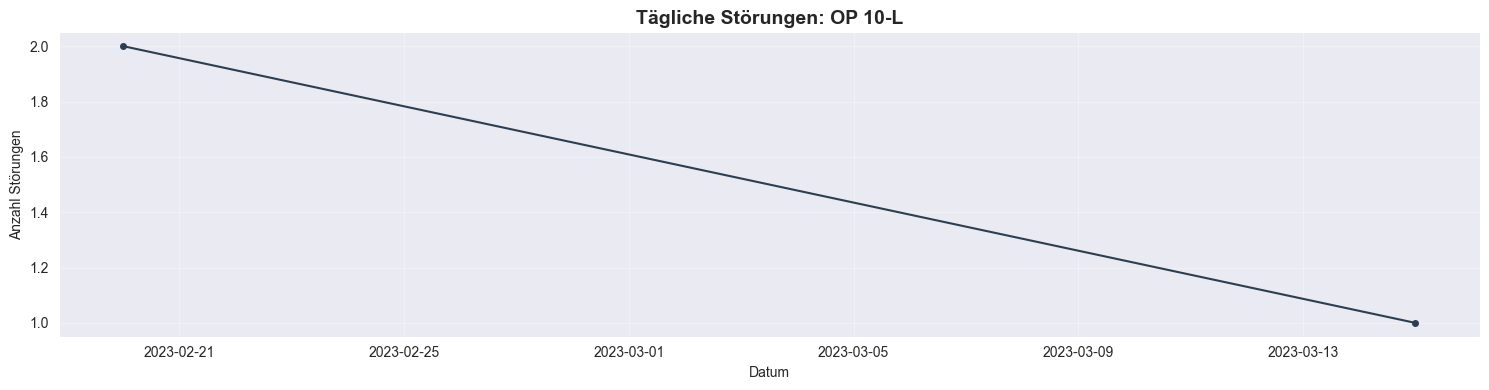

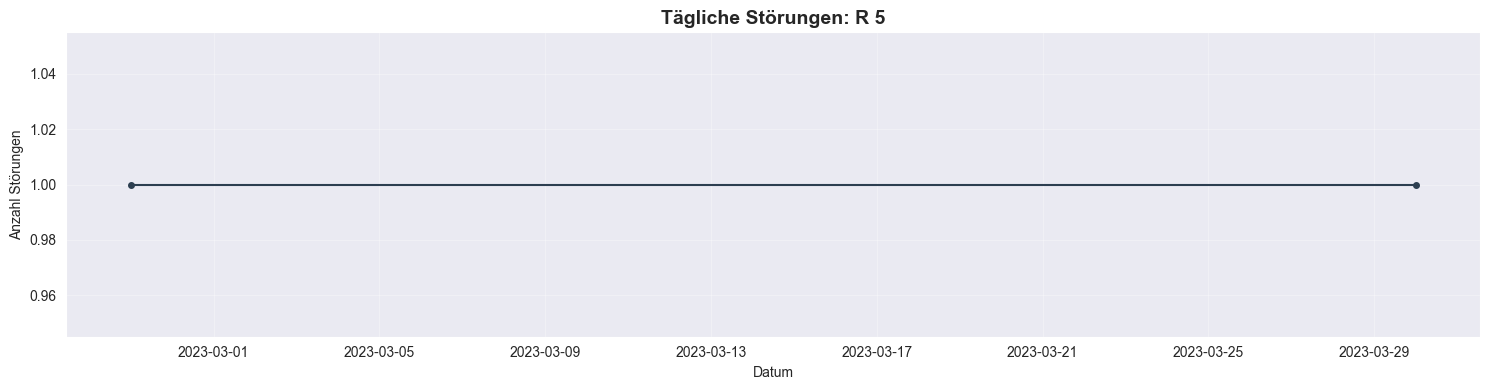

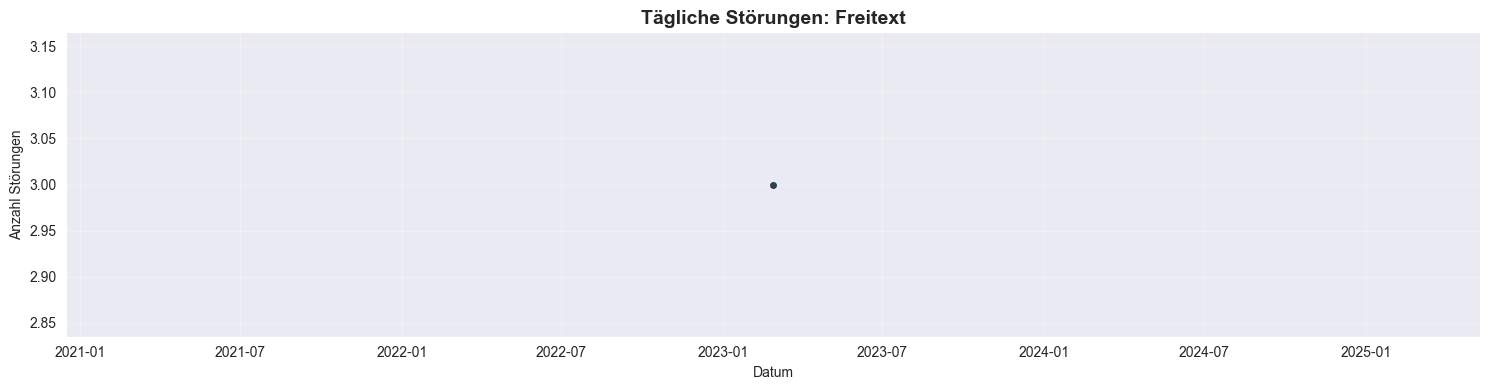

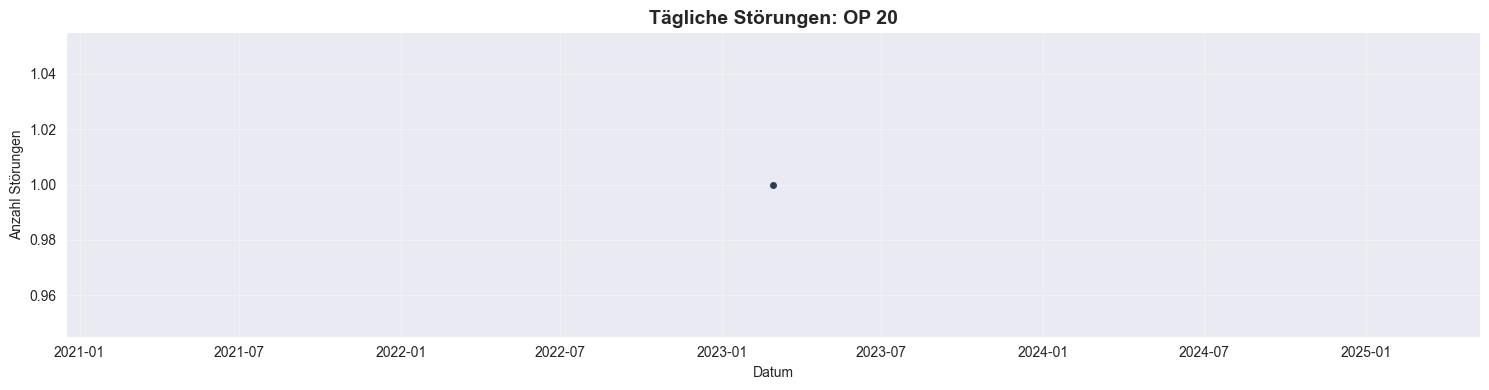

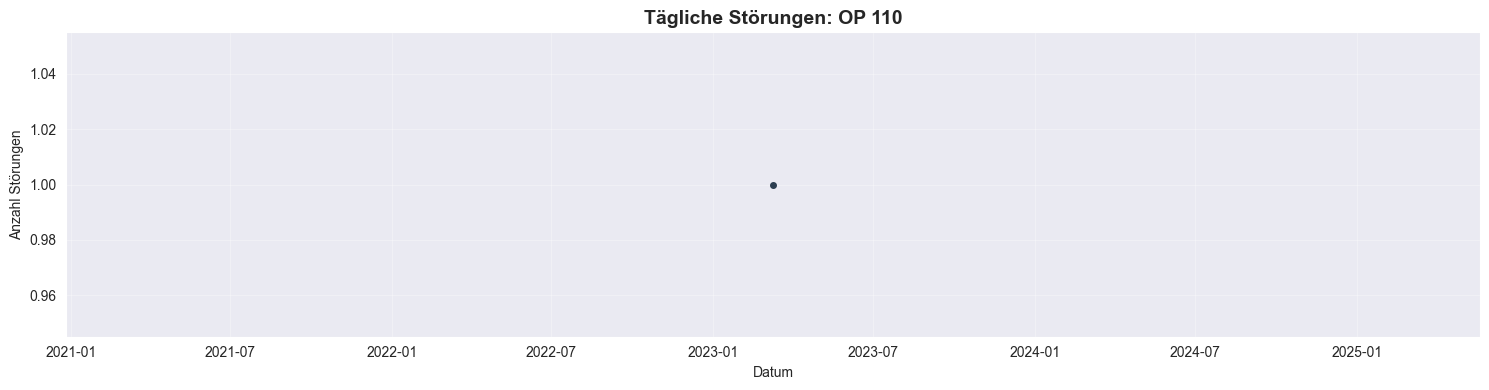

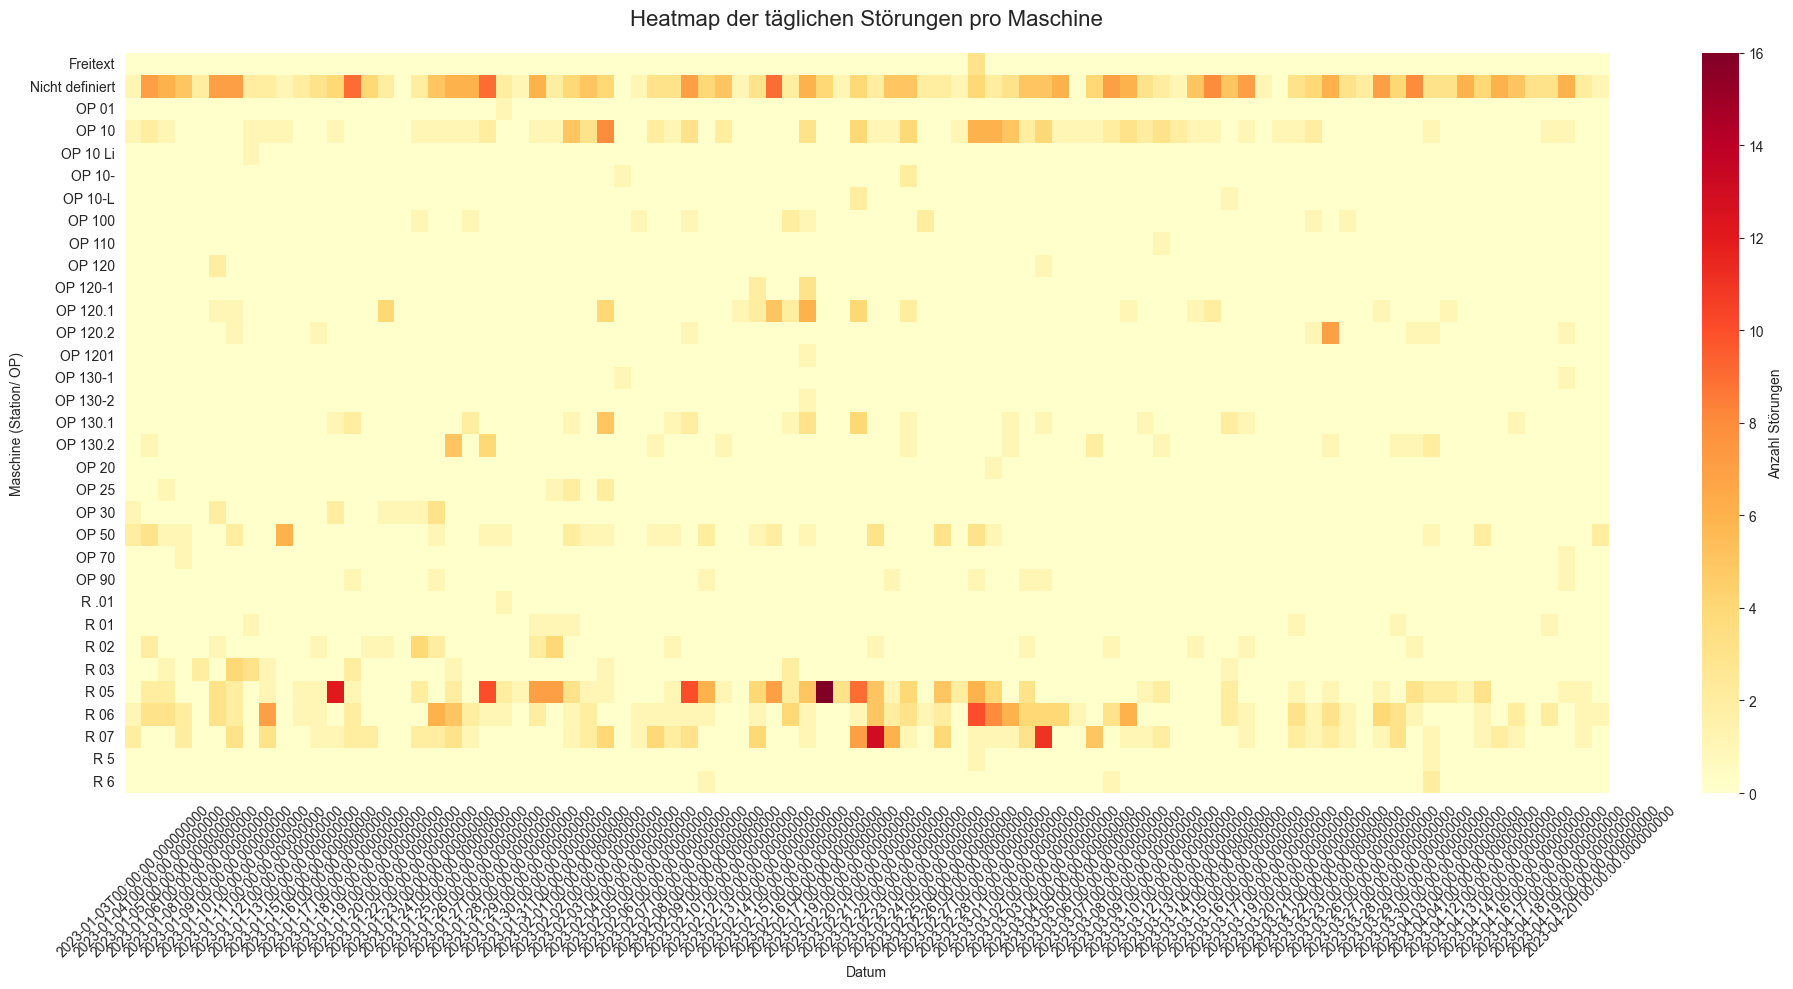

In [14]:


# 2. Datenreinigung & Vorbereitung
# Datum konvertieren
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')

# Spaltennamen für Ausfälle bereinigen (Störfaktoren wie Strings entfernen)
# Wir wandeln alles in Zahlen um, Fehler werden zu NaN und dann zu 0
cols_to_fix = ['Dauer Anlagen-Ausfall', 'Dauer Anlagen-Ausfall intern']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Maschinennamen bereinigen (NaN füllen, damit groupby nicht stolpert)
df['Station/ OP'] = df['Station/ OP'].fillna('Nicht definiert')

# 3. Störungs-Logik
# Eine Zeile gilt als Störung, wenn eine der Ausfall-Spalten > 0 ist
df['hat_stoerung'] = ((df['Dauer Anlagen-Ausfall'] > 0) | 
                      (df['Dauer Anlagen-Ausfall intern'] > 0)).astype(int)

# 4. Aggregation
# Wir zählen die Anzahl der Störungen pro Maschine und Tag
daily_faults = df[df['hat_stoerung'] == 1].groupby(['Station/ OP', 'Datum']).size().reset_index(name='Anzahl_Störungen')

# Falls der Datensatz groß ist, sortieren wir nach Datum für saubere Graphen
daily_faults = daily_faults.sort_values('Datum')

# --- VISUALISIERUNG 1: Liniendiagramme pro Maschine ---
machines = daily_faults['Station/ OP'].unique()

print(f"Generiere Diagramme für {len(machines)} Maschinen...")

for machine in machines:
    machine_data = daily_faults[daily_faults['Station/ OP'] == machine]
    
    # Nur plotten, wenn Daten vorhanden sind
    if not machine_data.empty:
        plt.figure(figsize=(15, 4))
        plt.plot(machine_data['Datum'], machine_data['Anzahl_Störungen'], 
                 marker='o', linestyle='-', color='#2c3e50', markersize=4)
        plt.title(f'Tägliche Störungen: {machine}', fontsize=14, fontweight='bold')
        plt.xlabel('Datum')
        plt.ylabel('Anzahl Störungen')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# --- VISUALISIERUNG 2: Heatmap ---
# Pivot-Tabelle erstellen
heatmap_data = daily_faults.pivot(index='Station/ OP', columns='Datum', values='Anzahl_Störungen').fillna(0)

if not heatmap_data.empty:
    plt.figure(figsize=(20, 10))
    sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Anzahl Störungen'})
    plt.title('Heatmap der täglichen Störungen pro Maschine', fontsize=16, pad=20)
    plt.xlabel('Datum')
    plt.ylabel('Maschine (Station/ OP)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Daten für die Heatmap verfügbar (evtl. keine Störungen > 0 gefunden).")